# Curvas de LTV e Matriz de Retenção | 2023 até abril/2026

Este notebook busca dados reais no BigQuery e **não cria dados fictícios**.

**Objetivos:**
- Curva de LTV por **canal** (DIGITAL, NAC, UNIDADES)
- Curva de LTV por **subcanal** (Paid Search, Paid Social, Sites Monomarca, Search Organic, CRM)
- Curva de LTV por **marca**
- Curva de LTV por **grupo de exames**
- **Matriz de Retenção × LTV** para canal, subcanal, marca e grupo de exames

**Como ler a curva:** o eixo X mostra quantos meses se passaram desde a aquisição do paciente; o eixo Y mostra o LTV médio acumulado por paciente.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from google.cloud import bigquery
from google.cloud import bigquery_storage

## 1. Configuração

Parâmetros principais. A data final é **exclusiva**:  significa que os dados vão até abril/2026.

In [2]:
CANAIS_ANALISE    = ["DIGITAL", "NAC", "UNIDADES"]
SUBCANAIS_ANALISE = ["Paid Search", "Paid Social", "Sites Monomarca", "Search Organic", "CRM Marketing", "Organic Social"]
GRUPOS_EXAMES    = ["AC", "RDI", "VACINA"]

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Marcas foco (lista que você passou) ---
MARCAS_FOCO = [
    "ALTA",
    "BORIS BERENSTEIN",
    "BRONSTEIN",
    "CDPI",
    "CERPE",
    "DELBONI",
    "EXAME",
    "FRISCHMANN AISENGART",
    "IMAGE MEMORIAL",
    "LAVOISIER",
    "LEME",
    "LUSTOSA",
    "SALOMAO E ZOPPI",
    "SANTA LUZIA",
    "SAO CAMILO",
    "SAO MARCOS",
    "SERGIO FRANCO",
]

## 2. Query

A query faz quatro coisas:

1. Lê atendimentos de 2023 até abril/2026.
2. Determina a **coorte de aquisição**: primeiro mês em que o paciente aparece como .
3. Soma a receita de cada paciente por mês a partir da aquisição.
4. Calcula o **LTV acumulado por coorte**, particionando por canal, subcanal, marca e grupo de exames juntos.

**Correções em relação à versão anterior:**
-  agora é calculado a partir da , **sem marca/grupo_exames** na chave — evita explosão de linhas duplicadas e garante que o denominador do LTV seja o total de pacientes únicos da coorte.
-  é calculada particionando por , ,  **apenas** (sem marca/grupo_exames), refletindo a coorte real.
- As colunas  e  são transportadas como atributos do **atendimento** (receita), não da coorte — um mesmo paciente pode ter atendimentos em marcas e grupos diferentes ao longo do tempo.

In [3]:
query = """
WITH base_eventos AS (
  SELECT
    nu_cpf_paciente                                       AS paciente_id,
    DATE_TRUNC(mes_atendimento, MONTH)                    AS mes_atendimento,
    COALESCE(origem_agd,     'Nao Identificado')          AS canal_aquisicao,
    COALESCE(
    CASE
      WHEN channel_group = 'CRM'
      THEN
        CASE
          WHEN REGEXP_CONTAINS(LOWER(COALESCE(campaign_non_direct,'')), r'(crcr|crmcore)')
            THEN 'CRM Marketing'
          ELSE 'CRM Transacional'
        END
      ELSE COALESCE(channel_group, 'Nao Identificado')
    END,
    'Nao Identificado'
  ) AS subcanal_aquisicao,
    COALESCE(marca,          'Nao Identificado')          AS marca,
    COALESCE(grupo_exames,   'Nao Identificado')          AS grupo_exames,
    classificacao_paciente_dasa,
    receita
  FROM prj-analytics-ga.testes.tb_temporal_class_pac_atd2
  WHERE mes_atendimento >= DATE '2023-01-01'
    AND mes_atendimento  < DATE '2026-05-01'
    AND classificacao_paciente_dasa IN ('novo', 'recorrente', 'recuperado')
),

-- Coorte: primeiro mês em que o paciente foi classificado como 'novo'
-- A chave da coorte é (paciente_id, canal, subcanal) — sem marca/grupo,
-- pois o paciente pertence a UMA coorte independentemente de onde gasta.
coorte_aquisicao AS (
  SELECT
    paciente_id,
    mes_atendimento  AS mes_coorte,
    canal_aquisicao,
    subcanal_aquisicao
  FROM base_eventos
  WHERE classificacao_paciente_dasa = 'novo'
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY paciente_id
    ORDER BY mes_atendimento ASC
  ) = 1
),

-- Tamanho da coorte: pacientes únicos por (canal, subcanal, mes_coorte)
tamanho_coorte AS (
  SELECT
    canal_aquisicao,
    subcanal_aquisicao,
    mes_coorte,
    COUNT(DISTINCT paciente_id) AS tamanho_coorte
  FROM coorte_aquisicao
  GROUP BY ALL
),

-- Receita mensal por paciente (soma de todos os atendimentos naquele mês)
receita_por_mes AS (
  SELECT
    paciente_id,
    mes_atendimento,
    -- Pega marca e grupo_exames do atendimento de MAIOR receita no mês
    -- (critério desempate: marca/grupo mais representativo do mês do paciente)
    ARRAY_AGG(marca        ORDER BY receita DESC LIMIT 1)[OFFSET(0)] AS marca,
    ARRAY_AGG(grupo_exames ORDER BY receita DESC LIMIT 1)[OFFSET(0)] AS grupo_exames,
    SUM(receita) AS receita_mes
  FROM base_eventos
  GROUP BY paciente_id, mes_atendimento
),

-- Junta coorte com receita e calcula mês relativo
coorte_receita AS (
  SELECT
    c.paciente_id,
    c.mes_coorte,
    c.canal_aquisicao,
    c.subcanal_aquisicao,
    r.mes_atendimento,
    r.marca,
    r.grupo_exames,
    DATE_DIFF(r.mes_atendimento, c.mes_coorte, MONTH) AS mes_desde_aquisicao,
    r.receita_mes
  FROM coorte_aquisicao c
  INNER JOIN receita_por_mes r
    ON  r.paciente_id   = c.paciente_id
    AND r.mes_atendimento >= c.mes_coorte
),

-- Agrega por (canal, subcanal, marca, grupo_exames, coorte, mes_relativo)
receita_mensal AS (
  SELECT
    canal_aquisicao,
    subcanal_aquisicao,
    marca,
    grupo_exames,
    mes_coorte,
    mes_atendimento,
    mes_desde_aquisicao,
    COUNT(DISTINCT paciente_id) AS pacientes_ativos,
    SUM(receita_mes)            AS receita_mes
  FROM coorte_receita
  GROUP BY ALL
),

-- Receita acumulada particionada por (canal, subcanal, mes_coorte)
-- Nota: marca e grupo_exames ficam como atributos do atendimento
base_final AS (
  SELECT
    r.canal_aquisicao,
    r.subcanal_aquisicao,
    r.marca,
    r.grupo_exames,
    r.mes_coorte,
    r.mes_atendimento,
    r.mes_desde_aquisicao,
    r.pacientes_ativos,
    c.tamanho_coorte,
    r.receita_mes,
    SUM(r.receita_mes) OVER (
      PARTITION BY r.canal_aquisicao, r.subcanal_aquisicao, r.mes_coorte
      ORDER BY r.mes_desde_aquisicao
      ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS receita_acumulada
  FROM receita_mensal r
  LEFT JOIN tamanho_coorte c
    ON  r.canal_aquisicao    = c.canal_aquisicao
    AND r.subcanal_aquisicao = c.subcanal_aquisicao
    AND r.mes_coorte         = c.mes_coorte
)

SELECT
  canal_aquisicao,
  subcanal_aquisicao,
  marca,
  grupo_exames,
  mes_coorte,
  mes_atendimento,
  mes_desde_aquisicao,
  pacientes_ativos,
  tamanho_coorte,
  ROUND(receita_mes,         2) AS receita_mes,
  ROUND(receita_acumulada,   2) AS receita_acumulada,
  ROUND(receita_acumulada / NULLIF(tamanho_coorte, 0), 2) AS ltv_medio_por_paciente
FROM base_final
ORDER BY canal_aquisicao, subcanal_aquisicao, mes_coorte, mes_desde_aquisicao
"""

## 3. Carregar dados

Executa a query no BigQuery. Se der erro aqui, o problema está em permissão, autenticação, nome da tabela ou nome de alguma coluna.

In [4]:
client          = bigquery.Client()
bqstorage_client = bigquery_storage.BigQueryReadClient()

df = client.query(query).result().to_dataframe(bqstorage_client=bqstorage_client)

df["mes_coorte"]          = pd.to_datetime(df["mes_coorte"])
df["mes_atendimento"]     = pd.to_datetime(df["mes_atendimento"])
df["mes_desde_aquisicao"] = df["mes_desde_aquisicao"].astype(int)

print(f"Linhas carregadas : {len(df):,}")
print(f"Coortes           : {df['mes_coorte'].min().date()} → {df['mes_coorte'].max().date()}")
print(f"Atendimentos      : {df['mes_atendimento'].min().date()} → {df['mes_atendimento'].max().date()}")
print()
print("Canais únicos     :", df["canal_aquisicao"].unique().tolist())
print("Subcanais únicos  :", df["subcanal_aquisicao"].unique().tolist())
print("Marcas únicas     :", df["marca"].nunique(), "marcas")
print("Grupos de exames  :", df["grupo_exames"].nunique(), "grupos")
df.head()


# Normalização simples: trim + upper (resolve 80% dos "não bateu")
df["marca_norm"] = df["marca"].astype(str).str.strip().str.upper()
MARCAS_FOCO_NORM = [m.strip().upper() for m in MARCAS_FOCO]

# (Opcional) Se quiser checar quais não estão batendo:
faltando = sorted(set(MARCAS_FOCO_NORM) - set(df["marca_norm"].unique()))
if faltando:
    print("⚠️ Marcas foco não encontradas no df (após normalização):", faltando)

Linhas carregadas : 282,147
Coortes           : 2023-01-01 → 2026-04-01
Atendimentos      : 2023-01-01 → 2026-04-01

Canais únicos     : ['DIGITAL', 'NAC', 'UNIDADES']
Subcanais únicos  : ['Blog', 'CRM Marketing', 'CRM Transacional', 'Dial My App', 'Direto', 'Fluxos NAC', 'IAs', 'Nao Identificado', 'Organic Social', 'Outros', 'Paid Search', 'Paid Social', 'QR Code', 'Referral', 'Search Organic', 'Sites Monomarca']
Marcas únicas     : 48 marcas
Grupos de exames  : 6 grupos


## 4. Funções de agregação e gráfico

Todas as transformações partem do dataframe carregado acima — nenhum dado novo é buscado.

**LTV acumulado médio:** soma da  das coortes ÷ soma do  das coortes (média ponderada).

In [5]:
# ── Formatação BR ─────────────────────────────────────────────────────────────
def formatar_reais(valor: float) -> str:
    """Formata número como moeda BR: R$ 1.234"""
    return f"R$ {valor:,.0f}".replace(",", "X").replace(".", ",").replace("X", ".")


# ── Curva LTV ──────────────────────────────────────────────────────────────────
def agregar_curva_ltv(
    df_base: pd.DataFrame,
    coluna_grupo: str,
    grupos: list[str]
) -> pd.DataFrame:
    """
    Calcula o LTV acumulado médio por mês relativo à aquisição.
    Usa receita_acumulada do SQL diretamente (já cumulativa por coorte).
    Média ponderada pelo tamanho de cada coorte.
    """
    df_plot = df_base[df_base[coluna_grupo].isin(grupos)].copy()
    if df_plot.empty:
        print(f"Nenhum dado para {coluna_grupo}: {grupos}")
        return df_plot

    mensal = (
        df_plot
        .groupby([coluna_grupo, "mes_desde_aquisicao"], as_index=False)
        .agg(
            receita_acumulada_total=("receita_acumulada", "sum"),
            pacientes=("tamanho_coorte", "sum"),
        )
    )
    mensal["ltv_acumulado"] = mensal["receita_acumulada_total"] / mensal["pacientes"]
    return mensal


def plotar_curva(
    df_curva: pd.DataFrame,
    coluna_grupo: str,
    grupos: list[str],
    titulo: str,
    caminho_saida: Path,
    max_meses: int | None = 24,          # <- limita janela (ex.: 24 meses) pra não esticar
    usar_quantile_y: bool = True,        # <- evita outlier explodir eixo
    q_inf: float = 0.02,
    q_sup: float = 0.98
) -> None:
    if df_curva.empty:
        return

    # Limita meses se necessário
    df_plot = df_curva.copy()
    if max_meses is not None:
        df_plot = df_plot[df_plot["mes_desde_aquisicao"] <= max_meses]

    # Ajusta tamanho em função do número de séries
    n_series = len(grupos)
    fig_h = min(10, 6 + 0.25 * max(0, n_series - 5))
    fig, ax = plt.subplots(figsize=(17, fig_h))

    # Plota
    for grupo in grupos:
        dados = df_plot[df_plot[coluna_grupo] == grupo].sort_values("mes_desde_aquisicao")
        if dados.empty:
            continue

        ax.plot(
            dados["mes_desde_aquisicao"],
            dados["ltv_acumulado"],
            marker="o",
            markersize=4,
            linewidth=2.2,
            label=grupo,
        )

    # Eixos / limites
    max_mes = int(df_plot["mes_desde_aquisicao"].max()) if not df_plot.empty else 0
    ax.set_xlim(0, max_mes + 1)

    # Controle de outliers no eixo Y (evita “explodido”)
    if usar_quantile_y and df_plot["ltv_acumulado"].notna().any():
        y0 = df_plot["ltv_acumulado"].quantile(q_inf)
        y1 = df_plot["ltv_acumulado"].quantile(q_sup)
        pad = (y1 - y0) * 0.08 if y1 > y0 else (y1 * 0.1 if y1 else 1)
        ax.set_ylim(max(0, y0 - pad), y1 + pad)

    ax.set_title(titulo, fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Meses desde a aquisição")
    ax.set_ylabel("LTV médio por paciente")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: formatar_reais(x)))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="y", alpha=0.3)
    ax.grid(axis="x", alpha=0.15)

    # Legenda: se tiver muita série, compacta
    if n_series <= 10:
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout(rect=[0, 0, 0.84, 1])
    else:
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=9)
        plt.tight_layout()

    plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
plt.show()

## Matriz Retenção × LTV

A matriz posiciona cada segmento em dois eixos:
- **Eixo X** — taxa de retenção no mês de referência (pacientes ainda ativos ÷ tamanho original da coorte)
- **Eixo Y** — LTV acumulado médio até o mês de referência

O tamanho do ponto é proporcional ao volume de pacientes adquiridos.

**Correção em relação à versão anterior:** a função agora filtra corretamente apenas as coortes que já completaram o  (coortes *elegíveis*), evitando sub-estimativa de retenção em coortes jovens.

In [6]:
def criar_matriz_retencao_ltv(
    df_base,
    coluna_grupo: str,
    grupos=None,
    mes_referencia: int = 12
) -> pd.DataFrame:
    """
    Calcula LTV acumulado e taxa de retenção no mes_referencia para cada grupo.

    Retorna um DataFrame com colunas:
    <coluna_grupo>, ltv_final, retencao, volume_pacientes, coortes_elegiveis, mes_referencia.
    """
    df_m = df_base.copy()
    if grupos is not None:
        df_m = df_m[df_m[coluna_grupo].isin(grupos)].copy()

    if df_m.empty:
        print("Base vazia após filtro.")
        return pd.DataFrame()

    data_fim = df_m["mes_atendimento"].max()
    resultados = []

    for grupo, g in df_m.groupby(coluna_grupo):

        # Identifica coortes elegíveis (já completaram mes_referencia)
        coortes_info = (
            g[["canal_aquisicao", "subcanal_aquisicao", "mes_coorte", "tamanho_coorte"]]
            .drop_duplicates()
        )

        coortes_info = coortes_info.assign(
            idade_meses=(
                (data_fim.year - coortes_info["mes_coorte"].dt.year) * 12
                + (data_fim.month - coortes_info["mes_coorte"].dt.month)
            )
        )

        elegiveis = coortes_info[coortes_info["idade_meses"] >= mes_referencia].copy()
        volume_total = coortes_info["tamanho_coorte"].sum()

        if elegiveis.empty:
            resultados.append({
                coluna_grupo: grupo,
                "ltv_final": np.nan,
                "retencao": np.nan,
                "volume_pacientes": volume_total,
                "coortes_elegiveis": 0,
                "mes_referencia": mes_referencia,
            })
            continue

        chave_coorte = ["canal_aquisicao", "subcanal_aquisicao", "mes_coorte"]
        g_eleg = g.merge(elegiveis[chave_coorte], on=chave_coorte, how="inner")

        # Linhas no mes_referencia
        g_mes = g_eleg[g_eleg["mes_desde_aquisicao"] == mes_referencia].copy()
        tamanho_eleg = elegiveis["tamanho_coorte"].sum()

        if g_mes.empty or tamanho_eleg <= 0:
            ltv = np.nan
            retencao = np.nan
        else:
            ltv = g_mes["receita_acumulada"].sum() / tamanho_eleg
            retencao = g_mes["pacientes_ativos"].sum() / tamanho_eleg

        resultados.append({
            coluna_grupo: grupo,
            "ltv_final": ltv,
            "retencao": retencao,
            "volume_pacientes": volume_total,
            "coortes_elegiveis": len(elegiveis),
            "mes_referencia": mes_referencia,
        })

    return pd.DataFrame(resultados)


def plotar_matriz(
    df_matriz: pd.DataFrame,
    coluna_grupo: str,
    titulo: str,
    caminho_saida: Path = None
) -> None:
    """Plota a Matriz Retenção × LTV com quadrantes (robusta no VS Code)."""

    # Sempre cria a figura (mesmo se não houver dados válidos)
    fig, ax = plt.subplots(figsize=(14, 8))

    # Filtra pontos válidos
    dados = df_matriz.dropna(subset=["ltv_final", "retencao"]).copy()

    # Caso não tenha ponto válido: mostra mensagem no próprio gráfico
    if dados.empty:
        ax.axis("off")
        ax.text(
            0.5, 0.5,
            "Sem dados suficientes para plotar a matriz.\n"
            "Verifique se existem coortes elegíveis no mês de referência\n"
            "e se ltv_final/retencao não estão NaN.",
            ha="center", va="center",
            fontsize=12, fontweight="bold",
            transform=ax.transAxes
        )
        ax.set_title(titulo, fontsize=15, fontweight="bold", pad=15)
        plt.tight_layout()

        if caminho_saida:
            plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
            print(f"Imagem salva: {caminho_saida}")

        plt.show()
        plt.close(fig)
        return

    # Cortes (medianas)
    corte_ltv = dados["ltv_final"].median()
    corte_retencao = dados["retencao"].median()

    # Tamanho das bolhas (safe)
    vol_max = dados["volume_pacientes"].max()
    if pd.isna(vol_max) or vol_max <= 0:
        tamanhos = np.full(len(dados), 250.0)
    else:
        tamanhos = (dados["volume_pacientes"] / vol_max) * 1800

    ax.scatter(
        dados["retencao"],
        dados["ltv_final"],
        s=tamanhos,
        alpha=0.6,
        edgecolor="black",
        linewidth=1.2,
    )

    # Labels dos pontos
    for _, row in dados.iterrows():
        ax.annotate(
            str(row[coluna_grupo]),
            xy=(row["retencao"], row["ltv_final"]),
            xytext=(8, 4),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            clip_on=True
        )

    # Linhas de corte
    ax.axvline(corte_retencao, linestyle="--", linewidth=1.5, color="#1976d2", alpha=0.8)
    ax.axhline(corte_ltv,      linestyle="--", linewidth=1.5, color="#1976d2", alpha=0.8)

    # Quadrantes (posição fixa no eixo)
    quadrantes = [
        (0.02, 0.02, "⬇ Rever aquisição\nRetenção baixa + LTV baixo"),
        (0.52, 0.02, "⬆ Fidelizados pouco rentáveis\nRetenção alta + LTV baixo"),
        (0.02, 0.52, "★ Nicho premium\nRetenção baixa + LTV alto"),
        (0.52, 0.52, "✦ Clientes ideais\nRetenção alta + LTV alto"),
    ]

    for xq, yq, label in quadrantes:
        ax.text(
            xq, yq, label,
            transform=ax.transAxes,
            fontsize=9,
            alpha=0.65,
            fontstyle="italic",
            va="bottom",
            ha="left",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.55,
                edgecolor="none"
            ),
            clip_on=True
        )

    # Títulos/eixos
    mes_ref = int(dados["mes_referencia"].iloc[0])
    ax.set_title(f"{titulo} | Mês {mes_ref}", fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel(f"Retenção no mês {mes_ref}", fontsize=12)
    ax.set_ylabel("LTV acumulado médio por paciente", fontsize=12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: formatar_reais(x)))
    ax.grid(alpha=0.25)

    plt.tight_layout()

    # Salva (se pediu)
    if caminho_saida:
        plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
        print(f"Imagem salva: {caminho_saida}")

    # Mostra sempre (VS Code / Jupyter)
    plt.show()
    plt.close(fig)

## 10. Matriz Retenção × LTV por Canal

,canal_aquisicao,ltv_final,retencao,volume_pacientes,coortes_elegiveis,mes_referencia
0,DIGITAL,4.419880e+05,0.061354,486020,321,12
1,NAC,1.044977e+06,0.053631,1142524,28,12
2,UNIDADES,7.871737e+05,0.059476,4944637,28,12


Imagem salva: outputs\matriz_retencao_canal_mes12.png


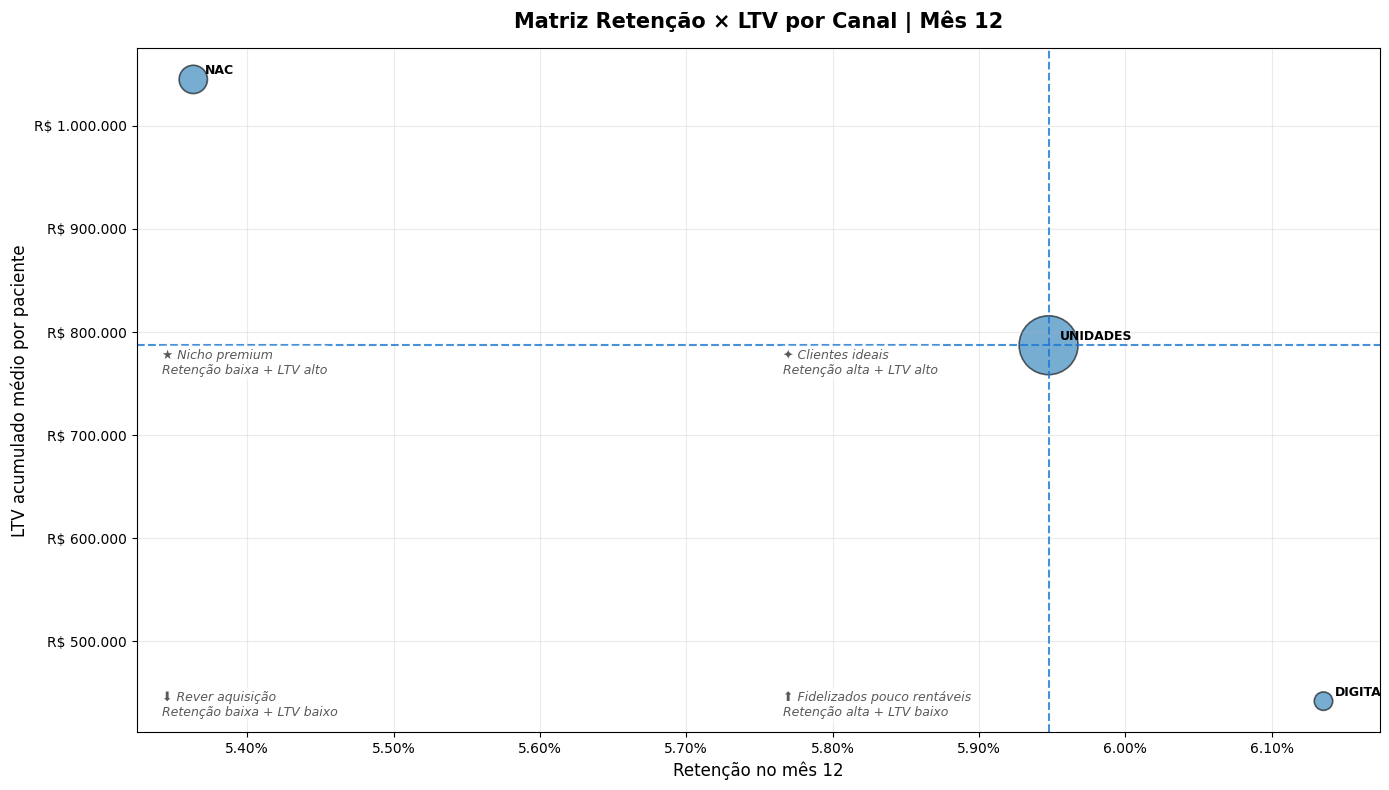

In [7]:
MES_REFERENCIA = 12

matriz_canais = criar_matriz_retencao_ltv(
    df_base=df,
    coluna_grupo="canal_aquisicao",
    grupos=CANAIS_ANALISE,
    mes_referencia=MES_REFERENCIA,
)
display(matriz_canais)

plotar_matriz(
    matriz_canais,
    coluna_grupo="canal_aquisicao",
    titulo="Matriz Retenção × LTV por Canal",
    caminho_saida=OUTPUT_DIR / f"matriz_retencao_canal_mes{MES_REFERENCIA}.png",
)

## 11. Matriz Retenção × LTV por Subcanal

,subcanal_aquisicao,ltv_final,retencao,volume_pacientes,coortes_elegiveis,mes_referencia
0,CRM Marketing,11606.897727,0.045455,86,10,12
1,Organic Social,240.075714,0.071429,130,11,12
2,Paid Search,389904.207707,0.058280,112335,28,12
3,Paid Social,3261.498892,0.023585,522,24,12
4,Search Organic,282864.151886,0.069059,30461,28,12
5,Sites Monomarca,448300.982325,0.055806,116664,28,12


Imagem salva: outputs\matriz_retencao_subcanal_mes12.png


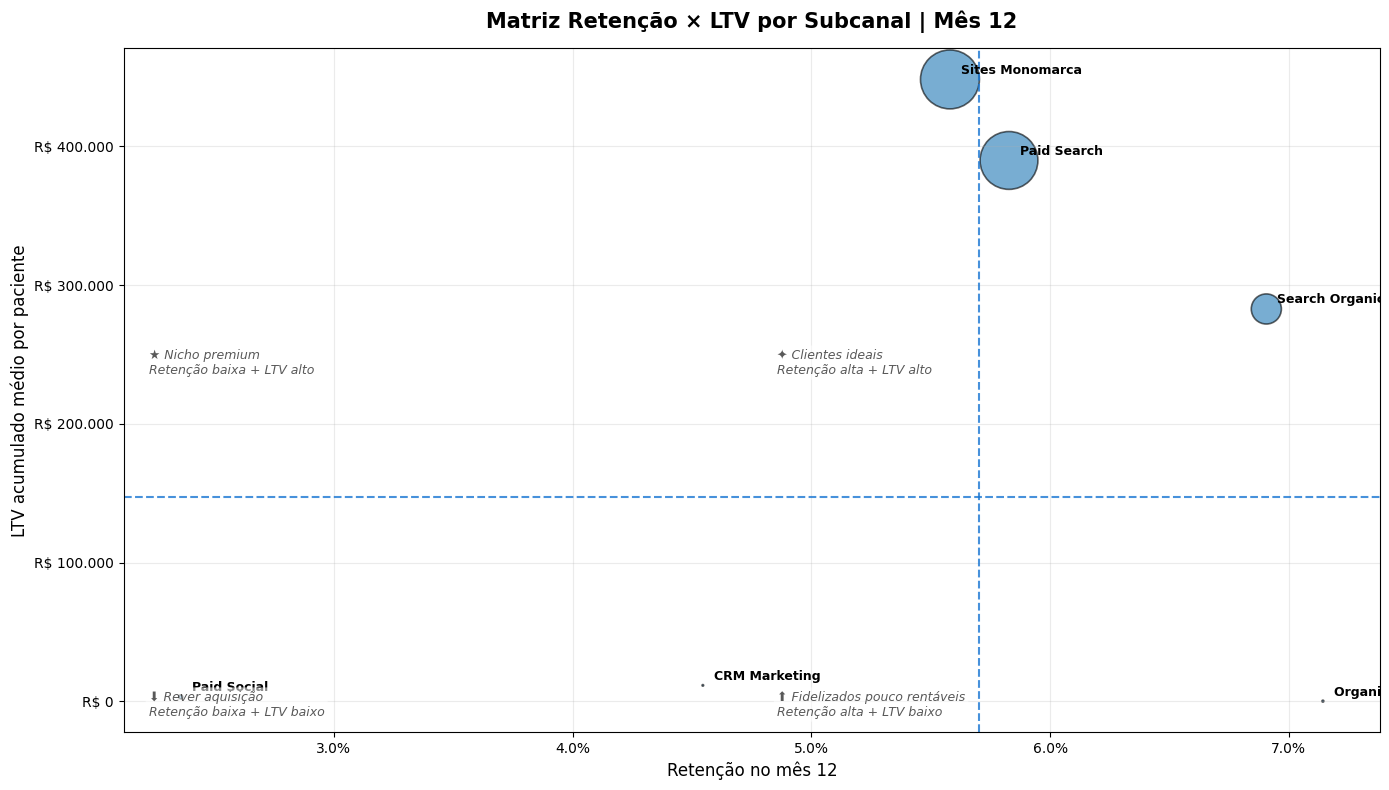

In [8]:
matriz_subcanais = criar_matriz_retencao_ltv(
    df_base=df,
    coluna_grupo="subcanal_aquisicao",
    grupos=SUBCANAIS_ANALISE,
    mes_referencia=MES_REFERENCIA,
)
display(matriz_subcanais)

plotar_matriz(
    matriz_subcanais,
    coluna_grupo="subcanal_aquisicao",
    titulo="Matriz Retenção × LTV por Subcanal",
    caminho_saida=OUTPUT_DIR / f"matriz_retencao_subcanal_mes{MES_REFERENCIA}.png",
)

---
## 15. Análises de Retenção e Oportunidades de CRM

As células a seguir complementam a análise com **5 perspectivas novas**:

| # | Análise | O que revela |
|---|---------|-------------|
| 15a | Curva de sobrevivência por canal | Em qual mês cada canal perde mais pacientes |
| 15b | Heatmap de retenção por coorte | Se a retenção está melhorando ao longo do tempo |
| 15c | Early drop-off (meses 1–4) | Diferença de LTV entre quem voltou e quem sumiu cedo |
| 15d | Simulador de impacto CRM | Quanto vale (R$) recuperar X% dos perdidos precoces |
| 15e | Janela ótima de reativação por subcanal | Em qual mês o CRM deve agir antes da janela fechar |


### 15c. Early Drop-off — Diferença de LTV entre quem voltou e quem sumiu nos primeiros 4 meses

Classifica cada combinação (canal, subcanal, coorte) em dois grupos:
- **Retido precoce**: houve pacientes ativos entre os meses 1 e 4
- **Perdido precoce**: nenhum paciente ativo registrado antes do mês 5

Depois compara o **LTV no mês 12** entre os dois grupos.  
Essa diferença é o *valor* que uma campanha de CRM na janela 1–4 pode recuperar.

C:\Users\F39860419825\AppData\Local\Temp\ipykernel_32260\1494479744.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,canal_aquisicao,subcanal_aquisicao,retornou_label,pacientes,ltv_medio,qtd_coortes
0,DIGITAL,CRM Marketing,Retido (meses 1–4),13,R$ 19.642,1.0
1,DIGITAL,CRM Transacional,Retido (meses 1–4),"4,106",R$ 14.563,27.0
2,DIGITAL,Dial My App,Retido (meses 1–4),2,R$ 42.667,1.0
3,DIGITAL,Direto,Retido (meses 1–4),"51,936",R$ 17.109,28.0
4,DIGITAL,Fluxos NAC,Retido (meses 1–4),"3,497",R$ 9.406,7.0
5,DIGITAL,Nao Identificado,Retido (meses 1–4),"83,421",R$ 16.971,28.0
6,DIGITAL,Organic Social,Perdido precoce,2,R$ 1.681,1.0
7,DIGITAL,Outros,Retido (meses 1–4),"12,869",R$ 15.372,28.0
8,DIGITAL,Paid Search,Retido (meses 1–4),"71,483",R$ 14.076,28.0
9,DIGITAL,Paid Social,Retido (meses 1–4),127,R$ 8.344,8.0


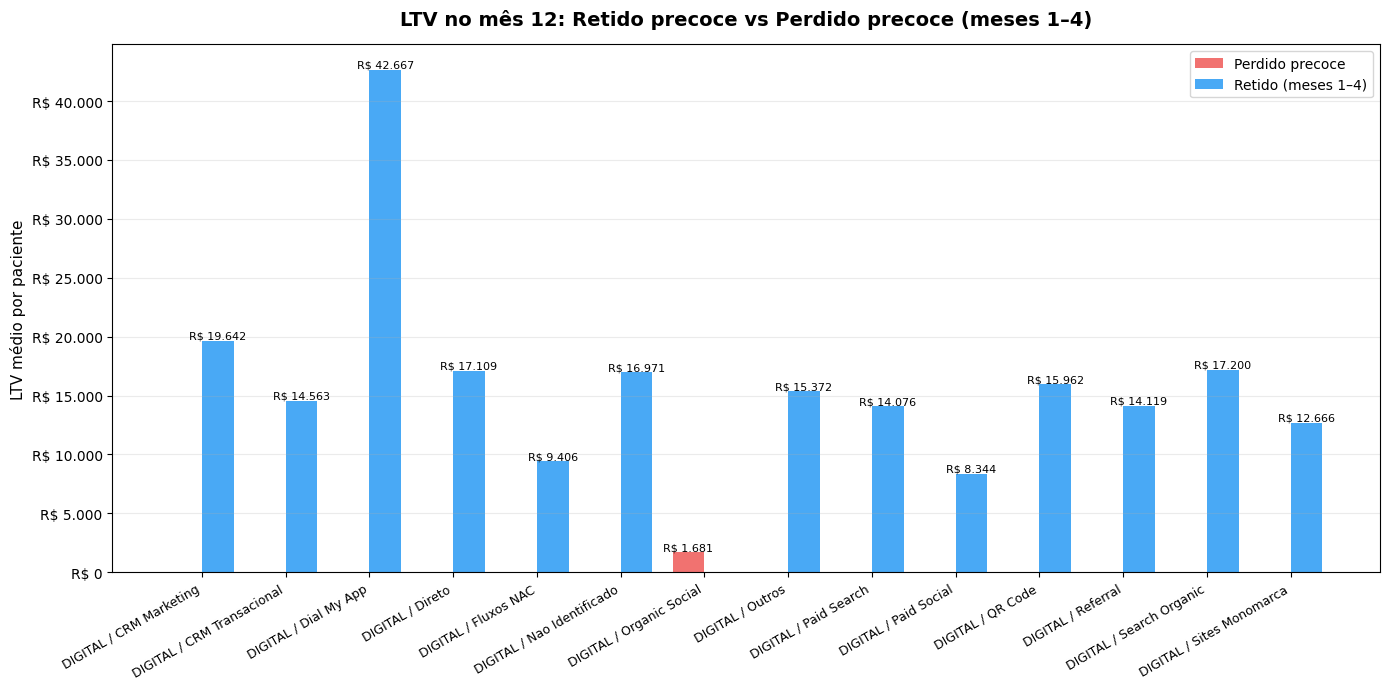

In [9]:
def calcular_early_dropoff(
    df_base: pd.DataFrame,
    janela: tuple = (1, 4),
    mes_ltv: int = 12,
) -> pd.DataFrame:
    """
    Para cada (canal_aquisicao, subcanal_aquisicao, mes_coorte):
    - retornou_em_janela: 1 se houve pacientes_ativos > 0 entre janela[0] e janela[1]
    - ltv_mes_ref      : ltv_medio_por_paciente no mes_ltv
    Retorna resumo agrupado por canal + subcanal + retornou_em_janela.
    """
    j0, j1 = janela

    # Flag de retorno na janela, por coorte
    flag = (
        df_base[
            df_base["mes_desde_aquisicao"].between(j0, j1)
        ]
        .groupby(["canal_aquisicao", "subcanal_aquisicao", "mes_coorte"], as_index=False)
        .agg(ativos_na_janela=("pacientes_ativos", "sum"))
        .assign(retornou_em_janela=lambda x: (x["ativos_na_janela"] > 0).astype(int))
    )

    # LTV no mes_ltv
    ltv_ref = (
        df_base[df_base["mes_desde_aquisicao"] == mes_ltv]
        .groupby(["canal_aquisicao", "subcanal_aquisicao", "mes_coorte"], as_index=False)
        .agg(
            ltv_coorte=("ltv_medio_por_paciente", "mean"),
            tamanho_coorte=("tamanho_coorte",      "first"),
        )
    )

    merged = ltv_ref.merge(
        flag[["canal_aquisicao", "subcanal_aquisicao", "mes_coorte", "retornou_em_janela"]],
        on=["canal_aquisicao", "subcanal_aquisicao", "mes_coorte"],
        how="left",
    ).fillna({"retornou_em_janela": 0})
    merged["retornou_em_janela"] = merged["retornou_em_janela"].astype(int)

    resumo = (
        merged
        .groupby(["canal_aquisicao", "subcanal_aquisicao", "retornou_em_janela"], as_index=False)
        .apply(
            lambda g: pd.Series({
                "qtd_coortes":    len(g),
                "pacientes":      g["tamanho_coorte"].sum(),
                "ltv_medio":      np.average(g["ltv_coorte"], weights=g["tamanho_coorte"]),
            })
        )
        .reset_index(drop=True)
    )
    resumo["retornou_label"] = resumo["retornou_em_janela"].map(
        {1: f"Retido (meses {j0}–{j1})", 0: f"Perdido precoce"}
    )
    resumo["mes_ltv"] = mes_ltv
    return resumo


def plotar_early_dropoff(df_ed: pd.DataFrame, mes_ltv: int = 12) -> None:
    """Gráfico de barras agrupadas: LTV retido vs perdido por canal/subcanal."""
    if df_ed.empty:
        print("Sem dados para plotar early drop-off.")
        return

    grupos = (
        df_ed
        .assign(eixo=df_ed["canal_aquisicao"] + " / " + df_ed["subcanal_aquisicao"])
    )
    pivot = grupos.pivot_table(
        index="eixo", columns="retornou_label", values="ltv_medio"
    ).fillna(0)

    x = np.arange(len(pivot))
    largura = 0.38
    cores = [ "#EF5350","#2196F3"]
    fig, ax = plt.subplots(figsize=(max(14, len(pivot) * 0.9), 7))

    for i, (col, cor) in enumerate(zip(pivot.columns, cores)):
        bars = ax.bar(x + i * largura, pivot[col], largura, label=col, color=cor, alpha=0.82)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2, h + 5,
                    formatar_reais(h), ha="center", va="bottom", fontsize=8,
                )

    ax.set_xticks(x + largura / 2)
    ax.set_xticklabels(pivot.index, rotation=30, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: formatar_reais(v)))
    ax.set_title(
        f"LTV no mês {mes_ltv}: Retido precoce vs Perdido precoce (meses 1–4)",
        fontsize=14, fontweight="bold", pad=14,
    )
    ax.set_ylabel("LTV médio por paciente", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "early_dropoff_ltv.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


df_ed = calcular_early_dropoff(
    # df[df["subcanal_aquisicao"].isin(SUBCANAIS_ANALISE)],
    df[df["canal_aquisicao"] == "DIGITAL"],
    # df,
    janela=(1, 4),
    mes_ltv=12,
)

# Tabela formatada
fmt_ed = df_ed.copy()
fmt_ed["ltv_medio"]  = df_ed["ltv_medio"].apply(formatar_reais)
fmt_ed["pacientes"]  = df_ed["pacientes"].apply(lambda v: f"{int(v):,}")
display(fmt_ed[[
    "canal_aquisicao", "subcanal_aquisicao", "retornou_label",
    "pacientes", "ltv_medio", "qtd_coortes",
]])

plotar_early_dropoff(df_ed, mes_ltv=12)


### 15d. Simulador de Impacto CRM

Usa os números reais da análise anterior para responder:  
**"Se o CRM recuperar X% dos pacientes perdidos precoces, quanto isso representa em R$?"**

O `custo_por_acao` é o custo unitário estimado de disparar uma campanha CRM para um paciente (email, SMS, push).  
Ajuste conforme o custo real da operação.


  SIMULADOR DE IMPACTO CRM  |  Custo por ação: R$ 8


,Canal,Subcanal,Perdidos precoces,Taxa de recuperação,Pacientes recuperados,Receita incremental,Custo campanha,Receita líquida,ROI
0,DIGITAL,Organic Social,2,5%,0,R$ -168,R$ 16,R$ -184,-1150%
1,DIGITAL,Organic Social,2,10%,0,R$ -336,R$ 16,R$ -352,-2201%
2,DIGITAL,Organic Social,2,15%,0,R$ -504,R$ 16,R$ -520,-3251%
3,DIGITAL,Organic Social,2,20%,0,R$ -672,R$ 16,R$ -688,-4301%
4,DIGITAL,Organic Social,2,30%,0,R$ -1.008,R$ 16,R$ -1.024,-6402%


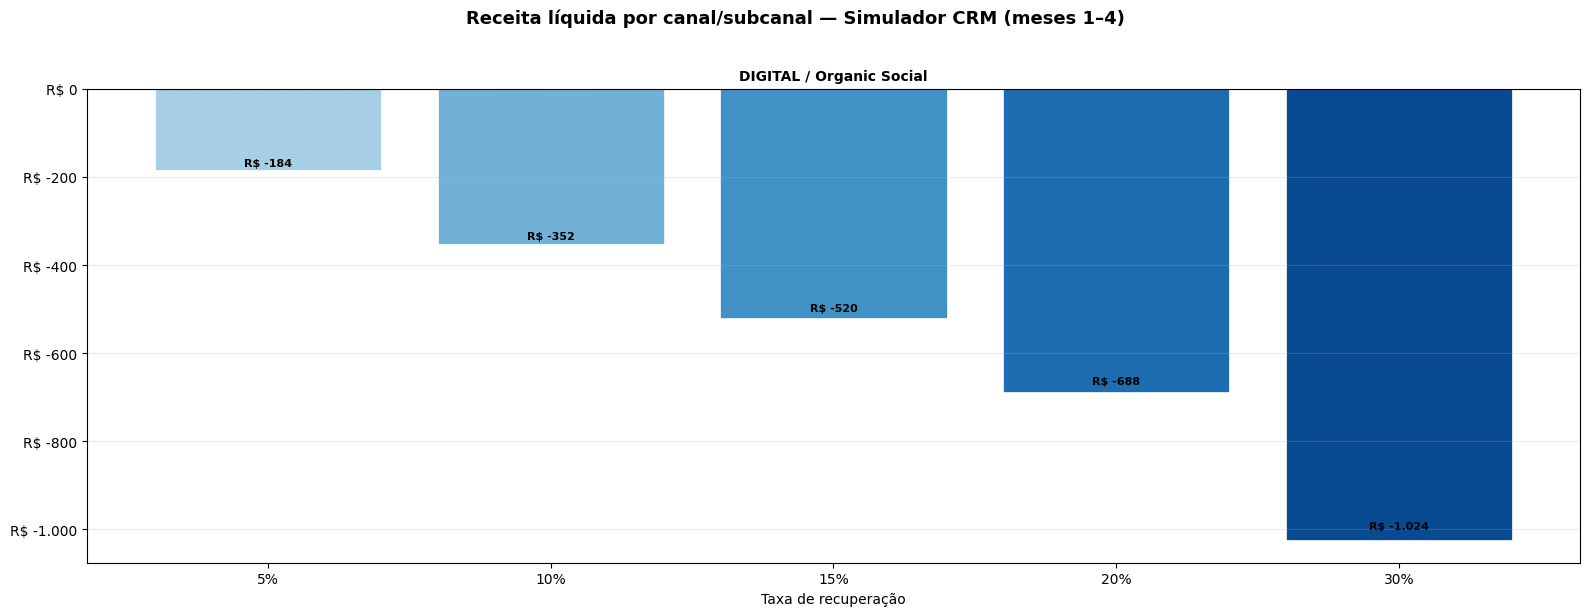

In [10]:
def simular_impacto_crm(
    df_ed: pd.DataFrame,
    taxas_recuperacao: tuple = (0.05, 0.10, 0.15, 0.20, 0.30),
    custo_por_acao: float = 8.0,
) -> None:
    """
    Para cada combinação canal/subcanal, calcula o impacto financeiro
    de recuperar diferentes percentuais dos pacientes perdidos precoces.

    Parâmetros:
        df_ed            : saída de calcular_early_dropoff()
        taxas_recuperacao: percentuais simulados de recuperação
        custo_por_acao   : custo unitário por paciente contatado pelo CRM (R$)
    """
    # Separa retidos e perdidos
    perdidos = df_ed[df_ed["retornou_em_janela"] == 0].copy()
    retidos  = df_ed[df_ed["retornou_em_janela"] == 1].copy()

    chave = ["canal_aquisicao", "subcanal_aquisicao"]
    merged = perdidos.merge(
        retidos[chave + ["ltv_medio"]].rename(columns={"ltv_medio": "ltv_retido"}),
        on=chave, how="left",
    ).rename(columns={"ltv_medio": "ltv_perdido", "pacientes": "qtd_perdidos"})
    merged["delta_ltv"] = merged["ltv_retido"].fillna(0) - merged["ltv_perdido"].fillna(0)

    registros = []
    for _, row in merged.iterrows():
        for taxa in taxas_recuperacao:
            recuperados    = row["qtd_perdidos"] * taxa
            receita_incr   = recuperados * row["delta_ltv"]
            custo_camp     = row["qtd_perdidos"] * custo_por_acao
            lucro_liq      = receita_incr - custo_camp
            roi            = (lucro_liq / custo_camp * 100) if custo_camp > 0 else np.nan
            registros.append({
                "Canal":                row["canal_aquisicao"],
                "Subcanal":             row["subcanal_aquisicao"],
                "Perdidos precoces":    int(row["qtd_perdidos"]),
                "Taxa de recuperação":  f"{taxa*100:.0f}%",
                "Pacientes recuperados":int(recuperados),
                "Receita incremental":  receita_incr,
                "Custo campanha":       custo_camp,
                "Receita líquida":      lucro_liq,
                "ROI":                  roi,
            })

    df_sim = pd.DataFrame(registros)

    # Formata para exibição
    fmt = df_sim.copy()
    for col in ["Receita incremental", "Custo campanha", "Receita líquida"]:
        fmt[col] = df_sim[col].apply(formatar_reais)
    fmt["ROI"] = df_sim["ROI"].apply(lambda v: f"{v:.0f}%" if pd.notna(v) else "—")
    fmt["Perdidos precoces"] = df_sim["Perdidos precoces"].apply(lambda v: f"{v:,}")
    fmt["Pacientes recuperados"] = df_sim["Pacientes recuperados"].apply(lambda v: f"{v:,}")

    print(f"\n{'='*80}")
    print(f"  SIMULADOR DE IMPACTO CRM  |  Custo por ação: {formatar_reais(custo_por_acao)}")
    print(f"{'='*80}")
    display(fmt)

    # Gráfico: receita líquida por canal/subcanal para cada taxa
    df_sim["eixo"] = df_sim["Canal"] + " / " + df_sim["Subcanal"]
    eixos = df_sim["eixo"].unique()
    taxas_str = [f"{t*100:.0f}%" for t in taxas_recuperacao]

    fig, axes = plt.subplots(
        1, len(eixos), figsize=(max(16, len(eixos) * 4.5), 6), sharey=False,
    )
    if len(eixos) == 1:
        axes = [axes]

    cores_barras = plt.cm.Blues(np.linspace(0.35, 0.9, len(taxas_recuperacao)))

    for ax, eixo in zip(axes, eixos):
        d_eixo = df_sim[df_sim["eixo"] == eixo]
        vals = d_eixo["Receita líquida"].values
        bars = ax.bar(taxas_str, vals, color=cores_barras, edgecolor="white", linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v + abs(v) * 0.02,
                formatar_reais(v), ha="center", va="bottom", fontsize=8, fontweight="bold",
            )
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.set_title(eixo, fontsize=10, fontweight="bold")
        ax.set_xlabel("Taxa de recuperação")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: formatar_reais(v)))
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle(
        "Receita líquida por canal/subcanal — Simulador CRM (meses 1–4)",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "simulador_crm.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return df_sim


# ── Executa com custo de R$ 8,00 por ação — ajuste conforme necessário ─────────
try:
    df_ed
except NameError:
    df_ed = calcular_early_dropoff(df, janela=(1, 4), mes_ltv=12)
    print("Variável 'df_ed' não encontrada. Calculando novamente a partir de df.")

df_simulacao = simular_impacto_crm(
    df_ed=df_ed,
    taxas_recuperacao=(0.05, 0.10, 0.15, 0.20, 0.30),
    custo_por_acao=8.0,
)


### 15e. Janela Ótima de Reativação por Subcanal

Mostra **em qual mês os pacientes costumam voltar naturalmente** por subcanal.  
Isso define o momento ideal para o CRM agir: **antes** da janela natural se fechar.

Ex.: se 40% dos retornos de *Paid Search* acontecem no mês 2,  
o CRM deve disparar no mês **1–1,5** — antes que a janela feche.


📌 Mês pico de retorno por subcanal (quando disparar CRM ANTES deste mês):
subcanal_aquisicao  mes_pico   pct_pico
     CRM Marketing         2  33.333333
    Organic Social         1       52.0
       Paid Search         1   18.79702
       Paid Social         1  17.412935
    Search Organic         1  20.553106
   Sites Monomarca         1  17.947247
Imagem salva: outputs\janela_reativacao_subcanal.png


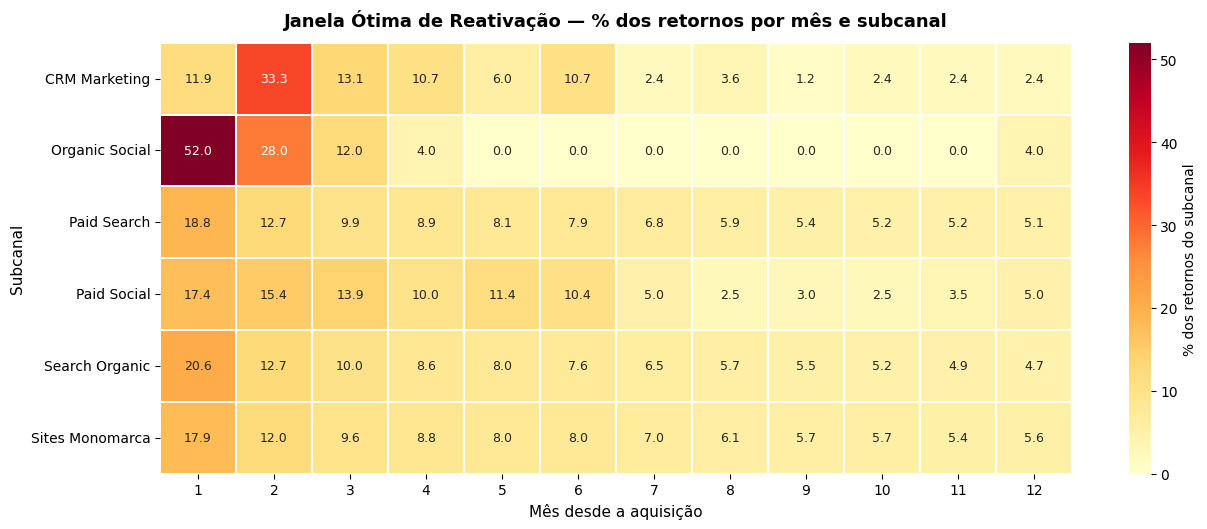

In [11]:
def plotar_janela_reativacao(
    df_base: pd.DataFrame,
    subcanais: list,
    max_mes: int = 12,
    caminho_saida: Path = None,
) -> pd.DataFrame:
    """
    Para cada subcanal, mostra a distribuição percentual dos retornos
    por mês relativo (entre meses 1 e max_mes, apenas onde houve atividade).
    """
    df_ret = df_base[
        df_base["subcanal_aquisicao"].isin(subcanais)
        & df_base["mes_desde_aquisicao"].between(1, max_mes)
        & (df_base["pacientes_ativos"] > 0)
    ].copy()

    dist = (
        df_ret
        .groupby(["subcanal_aquisicao", "mes_desde_aquisicao"], as_index=False)
        .agg(retornos=("pacientes_ativos", "sum"))
    )
    totais = dist.groupby("subcanal_aquisicao")["retornos"].transform("sum")
    dist["pct"] = dist["retornos"] / totais * 100

    # Mês modal (pico de retorno) por subcanal
    pico = (
        dist.loc[dist.groupby("subcanal_aquisicao")["pct"].idxmax()]
        [["subcanal_aquisicao", "mes_desde_aquisicao", "pct"]]
        .rename(columns={"mes_desde_aquisicao": "mes_pico", "pct": "pct_pico"})
    )

    print("\n📌 Mês pico de retorno por subcanal (quando disparar CRM ANTES deste mês):")
    print(pico.to_string(index=False))

    # Heatmap subcanal × mês
    pivot = dist.pivot(
        index="subcanal_aquisicao",
        columns="mes_desde_aquisicao",
        values="pct",
    ).fillna(0)
    pivot = pivot.astype(float)

    fig, ax = plt.subplots(figsize=(max(12, max_mes * 1.1), max(5, len(subcanais) * 0.9)))
    sns.heatmap(
        pivot, annot=True, fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.3,
        ax=ax,
        annot_kws={"size": 9},
        cbar_kws={"label": "% dos retornos do subcanal"},
    )
    ax.set_title(
        "Janela Ótima de Reativação — % dos retornos por mês e subcanal",
        fontsize=13, fontweight="bold", pad=12,
    )
    ax.set_xlabel("Mês desde a aquisição", fontsize=11)
    ax.set_ylabel("Subcanal", fontsize=11)
    plt.tight_layout()

    if caminho_saida:
        plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
        print(f"Imagem salva: {caminho_saida}")
    plt.show()
    plt.close(fig)
    return dist


df_janela = plotar_janela_reativacao(
    df_base=df,
    # subcanais=df["subcanal_aquisicao"].unique().tolist(),
    subcanais=SUBCANAIS_ANALISE,
    max_mes=12,
    caminho_saida=OUTPUT_DIR / "janela_reativacao_subcanal.png",
)



📌 Mês pico de retorno por Grupo de Exames (disparar CRM ANTES deste mês):
grupo_exames  mes_pico   pct_pico
          AC         1  12.837572
         RDI         1  22.144719
      VACINA         2  22.605097
Imagem salva: outputs\janela_reativacao_grupo_exames.png


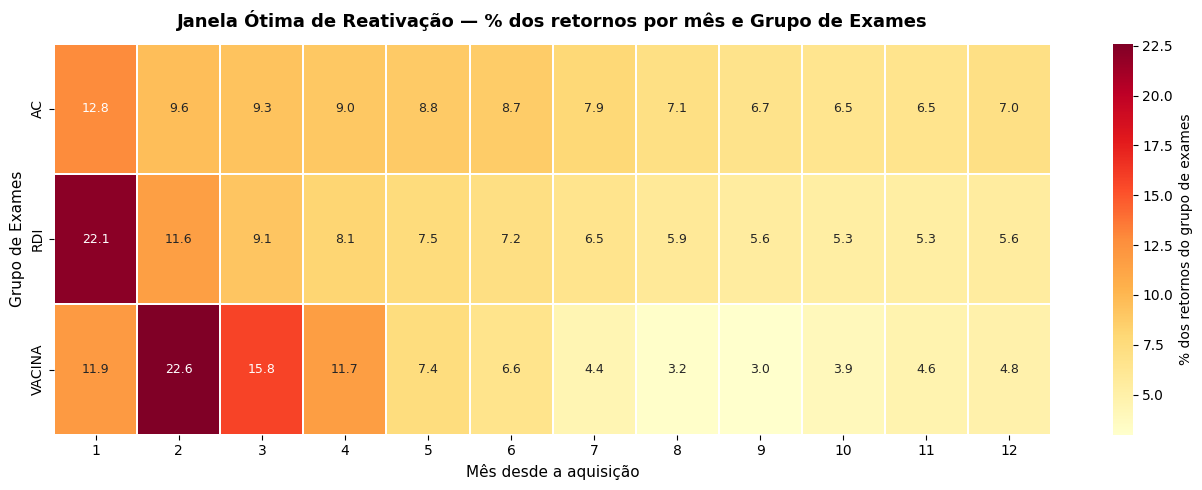

In [12]:
def plotar_janela_reativacao_por_grupo(
    df_base: pd.DataFrame,
    grupos: list,
    max_mes: int = 12,
    caminho_saida: Path = None,
) -> pd.DataFrame:
    """
    Para cada grupo de exames, mostra a distribuição percentual dos retornos
    por mês relativo (entre meses 1 e max_mes, apenas onde houve atividade).
    """
    # 1. Filtramos a base trocando 'subcanal_aquisicao' por 'grupo_exames'
    df_ret = df_base[
        df_base["grupo_exames"].isin(grupos)
        & df_base["mes_desde_aquisicao"].between(1, max_mes)
        & (df_base["pacientes_ativos"] > 0)
    ].copy()

    # 2. Agrupamos os retornos por grupo de exames e mês relativo
    dist = (
        df_ret
        .groupby(["grupo_exames", "mes_desde_aquisicao"], as_index=False)
        .agg(retornos=("pacientes_ativos", "sum"))
    )
    
    # 3. Calculamos a porcentagem (pct) de retorno sobre o total do próprio grupo
    totais = dist.groupby("grupo_exames")["retornos"].transform("sum")
    dist["pct"] = dist["retornos"] / totais * 100

    # 4. Encontramos o mês modal (o mês pico onde a maioria das pessoas volta)
    pico = (
        dist.loc[dist.groupby("grupo_exames")["pct"].idxmax()]
        [["grupo_exames", "mes_desde_aquisicao", "pct"]]
        .rename(columns={"mes_desde_aquisicao": "mes_pico", "pct": "pct_pico"})
    )

    print("\n📌 Mês pico de retorno por Grupo de Exames (disparar CRM ANTES deste mês):")
    print(pico.to_string(index=False))

    # 5. Montamos a tabela dinâmica (Pivot) para construir o Heatmap
    pivot = dist.pivot(
        index="grupo_exames",
        columns="mes_desde_aquisicao",
        values="pct",
    ).fillna(0)
    pivot = pivot.astype(float)

    # 6. Desenhamos o gráfico de calor na tela
    fig, ax = plt.subplots(figsize=(max(12, max_mes * 1.1), max(5, len(grupos) * 0.9)))
    sns.heatmap(
        pivot, annot=True, fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.3,
        ax=ax,
        annot_kws={"size": 9},
        cbar_kws={"label": "% dos retornos do grupo de exames"},
    )
    ax.set_title(
        "Janela Ótima de Reativação — % dos retornos por mês e Grupo de Exames",
        fontsize=13, fontweight="bold", pad=12,
    )
    ax.set_xlabel("Mês desde a aquisição", fontsize=11)
    ax.set_ylabel("Grupo de Exames", fontsize=11)
    plt.tight_layout()

    if caminho_saida:
        plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
        print(f"Imagem salva: {caminho_saida}")
    plt.show()
    plt.close(fig)
    return dist

# --- EXECUTANDO A FUNÇÃO ---
# Chamamos a nova função passando as variáveis originais do seu notebook
df_janela_grupo = plotar_janela_reativacao_por_grupo(
    df_base=df,
    grupos=GRUPOS_EXAMES,
    max_mes=12,
    caminho_saida=OUTPUT_DIR / "janela_reativacao_grupo_exames.png",
)


📌 Mês pico de retorno por Marca (disparar CRM ANTES deste mês):
               marca  mes_pico   pct_pico
                ALTA         1  14.649502
    BORIS BERENSTEIN         1  16.653941
           BRONSTEIN         1  15.244509
                CDPI         1  17.603312
               CERPE         1  13.329891
             DELBONI         1  17.611513
               EXAME         1  16.369347
FRISCHMANN AISENGART         1  11.756726
      IMAGE MEMORIAL         1  19.518266
           LAVOISIER         1  18.720384
                LEME         1   12.40103
             LUSTOSA         6   9.780415
     SALOMAO E ZOPPI         1  17.192106
         SANTA LUZIA         1  23.563498
          SAO CAMILO         1  13.511241
          SAO MARCOS         1  14.397685
       SERGIO FRANCO         1  13.432763
Imagem salva: outputs\janela_reativacao_marca.png


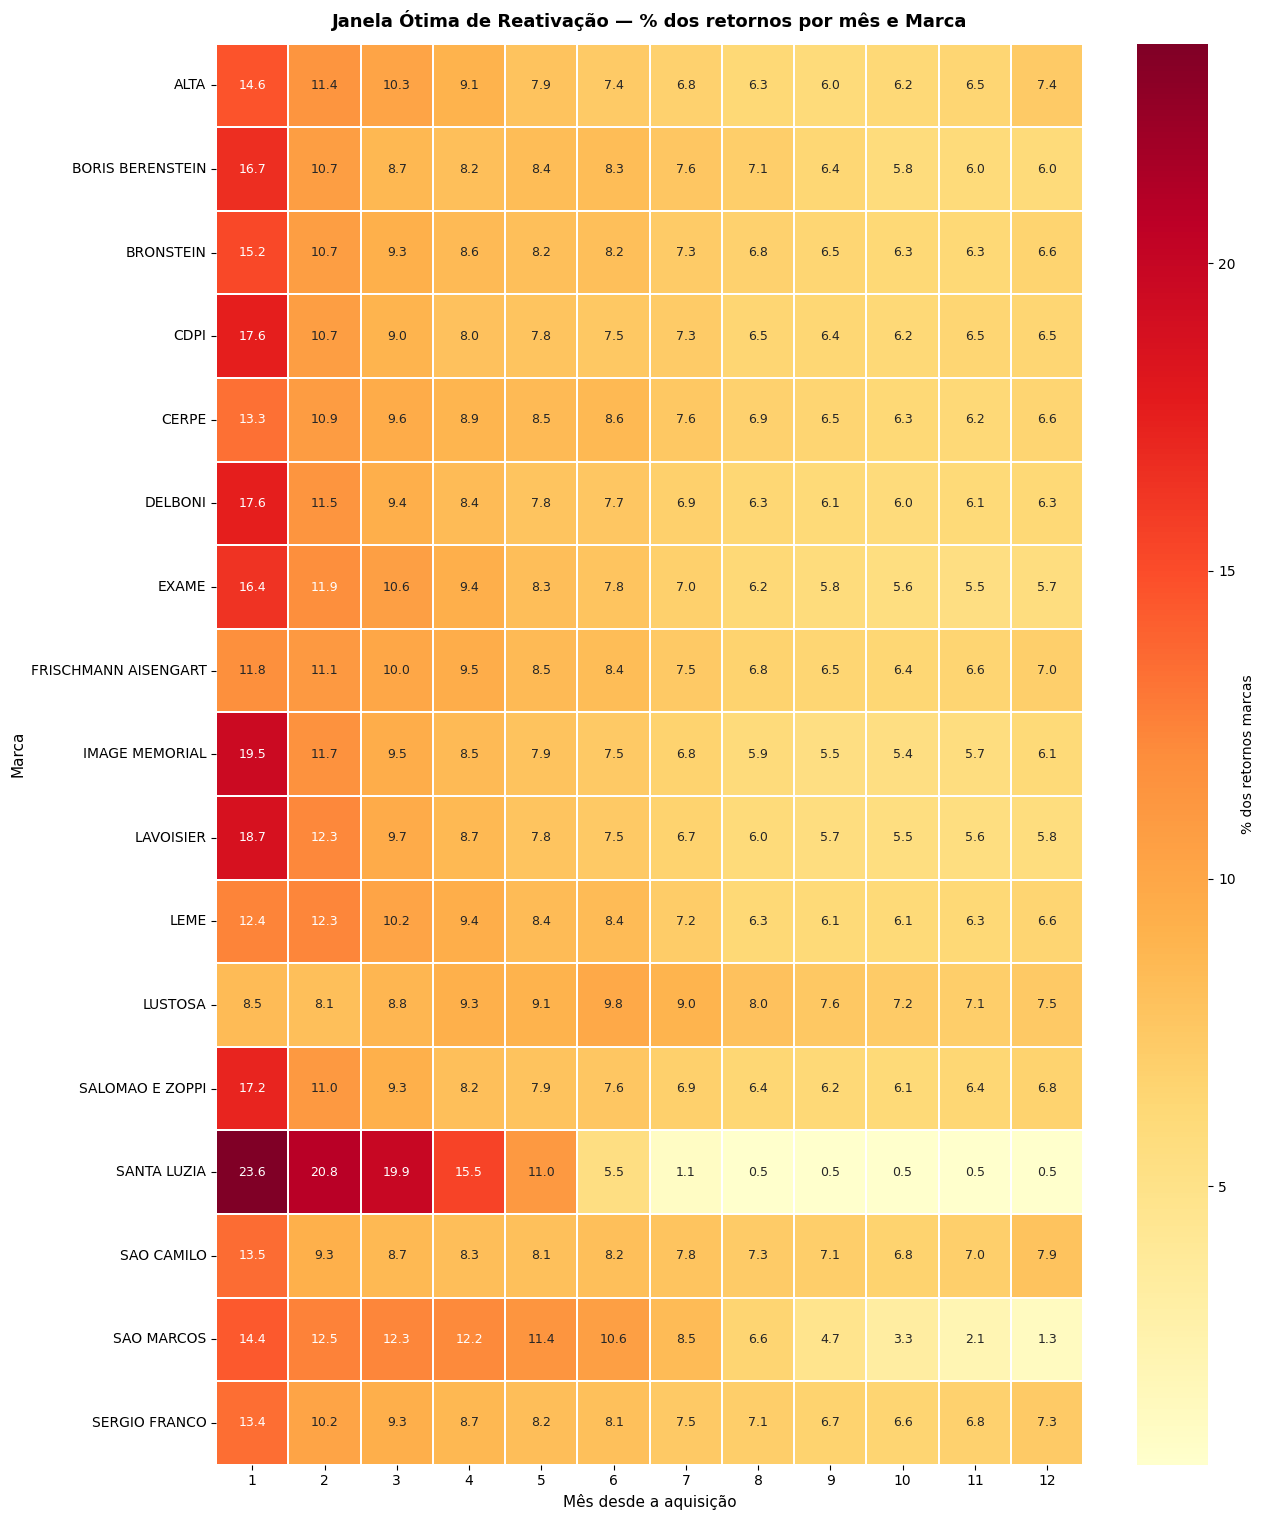

In [13]:
def plotar_janela_reativacao_por_marca(
    df_base: pd.DataFrame,
    grupos: list,
    max_mes: int = 12,
    caminho_saida: Path = None,
) -> pd.DataFrame:

    # 1. Filtramos a base trocando 'subcanal_aquisicao' por 'marca'
    df_ret = df_base[
        df_base["marca"].isin(grupos)
        & df_base["mes_desde_aquisicao"].between(1, max_mes)
        & (df_base["pacientes_ativos"] > 0)
    ].copy()

    # 2. Agrupamos os retornos por grupo de exames e mês relativo
    dist = (
        df_ret
        .groupby(["marca", "mes_desde_aquisicao"], as_index=False)
        .agg(retornos=("pacientes_ativos", "sum"))
    )
    
    # 3. Calculamos a porcentagem (pct) de retorno sobre o total do próprio grupo
    totais = dist.groupby("marca")["retornos"].transform("sum")
    dist["pct"] = dist["retornos"] / totais * 100

    # 4. Encontramos o mês modal (o mês pico onde a maioria das pessoas volta)
    pico = (
        dist.loc[dist.groupby("marca")["pct"].idxmax()]
        [["marca", "mes_desde_aquisicao", "pct"]]
        .rename(columns={"mes_desde_aquisicao": "mes_pico", "pct": "pct_pico"})
    )

    print("\n📌 Mês pico de retorno por Marca (disparar CRM ANTES deste mês):")
    print(pico.to_string(index=False))

    # 5. Montamos a tabela dinâmica (Pivot) para construir o Heatmap
    pivot = dist.pivot(
        index="marca",
        columns="mes_desde_aquisicao",
        values="pct",
    ).fillna(0)
    pivot = pivot.astype(float)

    # 6. Desenhamos o gráfico de calor na tela
    fig, ax = plt.subplots(figsize=(max(12, max_mes * 1.1), max(5, len(grupos) * 0.9)))
    sns.heatmap(
        pivot, annot=True, fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.3,
        ax=ax,
        annot_kws={"size": 9},
        cbar_kws={"label": "% dos retornos marcas"},
    )
    ax.set_title(
        "Janela Ótima de Reativação — % dos retornos por mês e Marca",
        fontsize=13, fontweight="bold", pad=12,
    )
    ax.set_xlabel("Mês desde a aquisição", fontsize=11)
    ax.set_ylabel("Marca", fontsize=11)
    plt.tight_layout()

    if caminho_saida:
        plt.savefig(caminho_saida, dpi=150, bbox_inches="tight")
        print(f"Imagem salva: {caminho_saida}")
    plt.show()
    plt.close(fig)
    return dist

# --- EXECUTANDO A FUNÇÃO ---
# Chamamos a nova função passando as variáveis originais do seu notebook
df_janela_marca = plotar_janela_reativacao_por_marca(
    df_base=df,
    grupos=MARCAS_FOCO,
    max_mes=12,
    caminho_saida=OUTPUT_DIR / "janela_reativacao_marca.png",
)

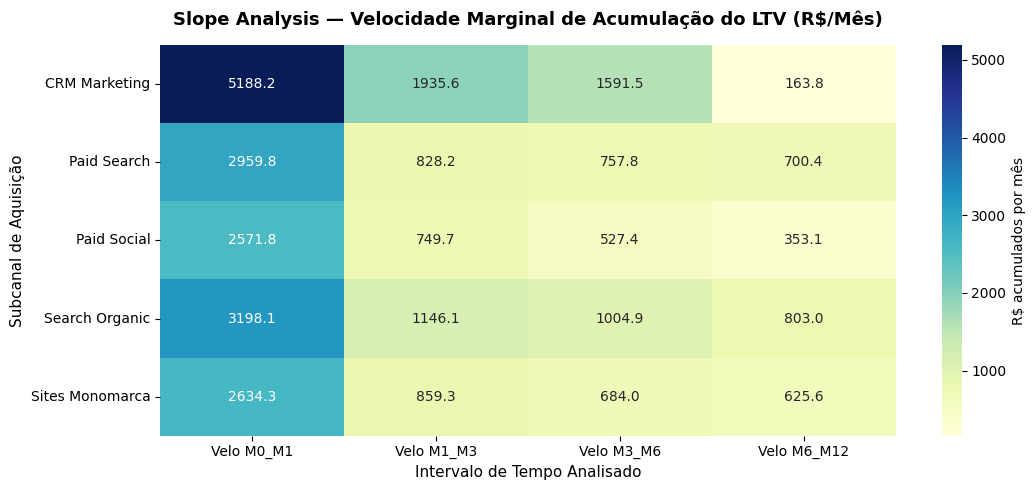

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def executar_slope_analysis(df_base, subcanais_foco, marcos=[0, 1, 3, 6, 12]):
    """
    Calcula a velocidade marginal mensal (variação do LTV / delta meses)
    entre os marcos de tempo estipulados.
    """
    # 1. Agrupar por subcanal e mes_desde_aquisicao (Média Ponderada)
    agrupado = df_base[df_base['subcanal_aquisicao'].isin(subcanais_foco)].groupby(
        ['subcanal_aquisicao', 'mes_desde_aquisicao']
    ).agg(
        receita_acum_total=('receita_acumulada', 'sum'),
        pacientes_totais=('tamanho_coorte', 'sum')
    ).reset_index()
    
    agrupado['ltv_ponderado'] = agrupado['receita_acum_total'] / agrupado['pacientes_totais']
    
    # 2. Pivotar para colocar meses como colunas
    pivot_ltv = agrupado.pivot(index='subcanal_aquisicao', columns='mes_desde_aquisicao', values='ltv_ponderado')
    
    # Garantir que temos todos os marcos necessários
    marcos = [m for m in marcos if m in pivot_ltv.columns]
    
    # 3. Calcular as velocidades marginais (inclinação)
    slopes = pd.DataFrame(index=pivot_ltv.index)
    
    for idx in range(len(marcos) - 1):
        m_inicio = marcos[idx]
        m_fim = marcos[idx+1]
        delta_t = m_fim - m_inicio
        col_name = f'Velo M{m_inicio}_M{m_fim}'
        
        # Fórmula do Slope: (LTV_fim - LTV_inicio) / Delta Meses
        slopes[col_name] = (pivot_ltv[m_fim] - pivot_ltv[m_inicio]) / delta_t
    
    # Converter para float e preencher NaN com 0 para evitar erro no heatmap
    slopes = slopes.astype(float).fillna(0)
        
    # Plotar o Heatmap de Velocidade
    plt.figure(figsize=(11, 5))
    sns.heatmap(slopes, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'R$ acumulados por mês'})
    plt.title("Slope Analysis — Velocidade Marginal de Acumulação do LTV (R$/Mês)", fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("Intervalo de Tempo Analisado", fontsize=11)
    plt.ylabel("Subcanal de Aquisição", fontsize=11)
    plt.tight_layout()
    plt.show()
    
    return slopes

# Execução (Exemplo usando os subcanais foco definidos no seu notebook)
SUBCANAIS_FOCO = ["Paid Search", "Paid Social", "Sites Monomarca", "Search Organic", "CRM Marketing"]
df_slopes = executar_slope_analysis(df, SUBCANAIS_FOCO)

C:\Users\F39860419825\AppData\Local\Temp\ipykernel_32260\2458339452.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dados['hazard_rate'].fillna(0, inplace=True)


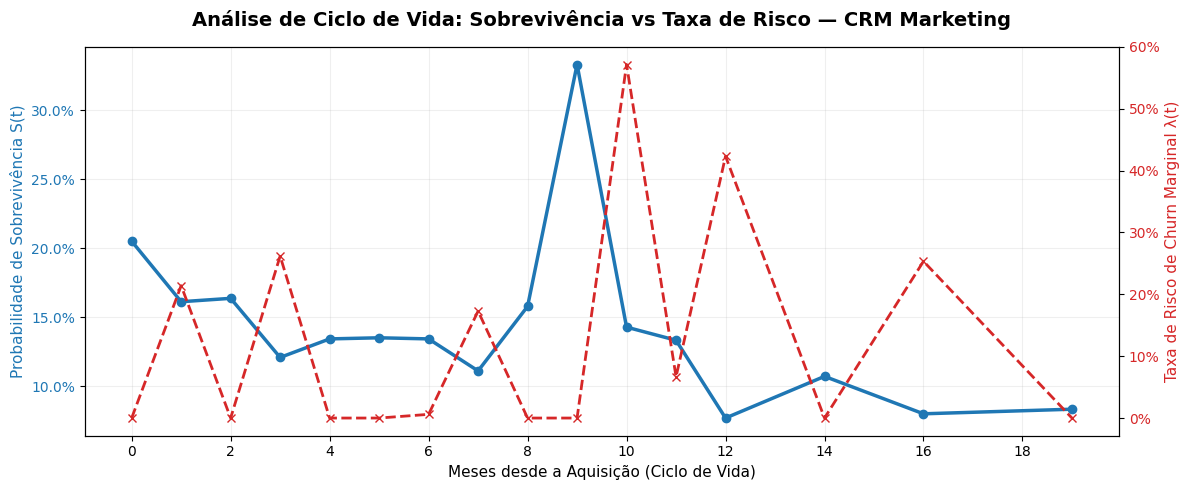

In [15]:
def plotar_survival_and_hazard(df_base, subcanal):
    # Filtrar dados do subcanal e agrupar meses desde a aquisição (Média Ponderada)
    dados = df_base[df_base['subcanal_aquisicao'] == subcanal].groupby('mes_desde_aquisicao').agg(
        ativos=('pacientes_ativos', 'sum'),
        total_safra=('tamanho_coorte', 'sum')
    ).reset_index()
    
# pacientes ativos / pacientes entrada(novos)(coorte)

    # 1. Curva de Sobrevivência S(t) aproximada pela taxa de retenção da coorte
    dados['survival_rate'] = dados['ativos'] / dados['total_safra']
    
    # 2. Hazard Rate Lambda(t) = [S(t-1) - S(t)] / S(t-1)
    dados['survival_anterior'] = dados['survival_rate'].shift(1)
    dados['hazard_rate'] = (dados['survival_anterior'] - dados['survival_rate']) / dados['survival_anterior']
    
    # Tratar inconsistências de amostragem na cauda longa (limitar entre 0 e 1)
    dados['hazard_rate'] = dados['hazard_rate'].clip(lower=0, upper=1)
    dados['hazard_rate'].fillna(0, inplace=True)
    
    # Plot Duplo
    fig, ax1 = plt.subplots(figsize=(12, 5))
    
    # Eixo 1: Sobrevivência
    color = '#1f77b4'
    ax1.set_xlabel('Meses desde a Aquisição (Ciclo de Vida)', fontsize=11)
    ax1.set_ylabel('Probabilidade de Sobrevivência S(t)', color=color, fontsize=11)
    ax1.plot(dados['mes_desde_aquisicao'], dados['survival_rate'], color=color, marker='o', linewidth=2.5, label='Sobrevivência')
    ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax1.grid(alpha=0.2)
    
    # Eixo 2: Risco (Hazard Rate)
    ax2 = ax1.twinx()  
    color = '#d62728'
    ax2.set_ylabel('Taxa de Risco de Churn Marginal λ(t)', color=color, fontsize=11)
    ax2.plot(dados['mes_desde_aquisicao'], dados['hazard_rate'], color=color, marker='x', linestyle='--', linewidth=2, label='Hazard Rate')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    
    plt.title(f'Análise de Ciclo de Vida: Sobrevivência vs Taxa de Risco — {subcanal}', fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()
    plt.show()
    
    return dados[['mes_desde_aquisicao', 'survival_rate', 'hazard_rate']]

# df_risco = plotar_survival_and_hazard(df, "Paid Search")
# df_risco = plotar_survival_and_hazard(df, "Paid Social")
# df_risco = plotar_survival_and_hazard(df, "Sites Monomarca")
df_risco = plotar_survival_and_hazard(df, "CRM Marketing")
# df_risco = plotar_survival_and_hazard(df, "Search Organic")

C:\Users\F39860419825\AppData\Local\Temp\ipykernel_32260\2701988581.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Subcanal', y='Risco no Pico (%)', data=df_resumo, palette='Reds_r', ax=ax)


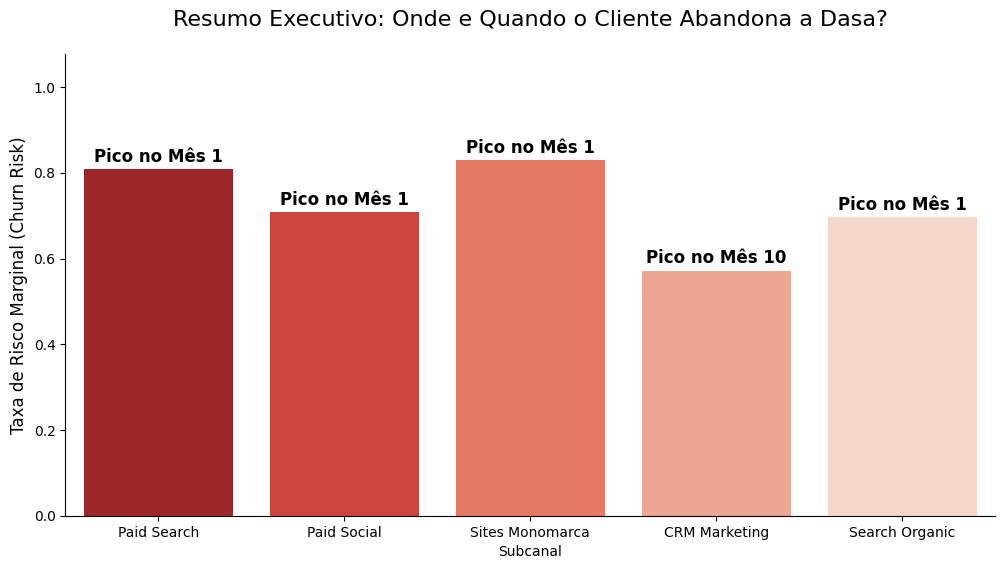

,Subcanal,Retenção (Mês 12),Mês de Maior Churn,Risco no Pico (%)
0,Paid Search,0.002095,1,0.807760
1,Paid Social,0.064935,1,0.708232
2,Sites Monomarca,0.001581,1,0.829126
3,CRM Marketing,0.076923,10,0.571429
4,Search Organic,0.004075,1,0.696684


In [16]:
def gerar_resumo_diretoria(df_base, lista_subcanais):
    resumo_executivo = []

    for subcanal in lista_subcanais:
        # Filtrar e calcular indicadores
        dados = df_base[df_base['subcanal_aquisicao'] == subcanal].groupby('mes_desde_aquisicao').agg(
            ativos=('pacientes_ativos', 'sum'),
            total_safra=('tamanho_coorte', 'sum')
        ).reset_index()
        
        # Sobrevivência (Retenção)
        dados['survival_rate'] = dados['ativos'] / dados['total_safra']
        
        # Risco (Hazard Rate)
        dados['survival_anterior'] = dados['survival_rate'].shift(1)
        dados['hazard_rate'] = (dados['survival_anterior'] - dados['survival_rate']) / dados['survival_anterior']
        dados['hazard_rate'] = dados['hazard_rate'].clip(lower=0, upper=1).fillna(0)

        # MÉTRICAS PARA O SLIDE
        retencao_m12 = dados[dados['mes_desde_aquisicao'] == 12]['survival_rate'].values[0] if 12 in dados['mes_desde_aquisicao'].values else 0
        pico_risco_mes = dados.loc[dados['hazard_rate'].idxmax(), 'mes_desde_aquisicao']
        valor_pico_risco = dados['hazard_rate'].max()
        
        resumo_executivo.append({
            'Subcanal': subcanal,
            'Retenção (Mês 12)': retencao_m12,
            'Mês de Maior Churn': pico_risco_mes,
            'Risco no Pico (%)': valor_pico_risco
        })

    df_resumo = pd.DataFrame(resumo_executivo)
    
    # Plotagem para o Slide
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Gráfico de barras mostrando o Risco Máximo por Canal
    bars = sns.barplot(x='Subcanal', y='Risco no Pico (%)', data=df_resumo, palette='Reds_r', ax=ax)
    
    # Adicionar os meses de pico em cima das barras para virar insight
    for i, p in enumerate(bars.patches):
        mes = df_resumo.iloc[i]['Mês de Maior Churn']
        ax.annotate(f"Pico no Mês {int(mes)}", 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=12, fontweight='bold')

    plt.title('Resumo Executivo: Onde e Quando o Cliente Abandona a Dasa?', fontsize=16, pad=20)
    plt.ylabel('Taxa de Risco Marginal (Churn Risk)', fontsize=12)
    plt.ylim(0, df_resumo['Risco no Pico (%)'].max() * 1.3)
    sns.despine()
    plt.show()

    return df_resumo

# Execução
canais = ["Paid Search", "Paid Social", "Sites Monomarca", "CRM Marketing", "Search Organic"]
df_consolidado = gerar_resumo_diretoria(df, canais)
display(df_consolidado)

In [17]:
query_whale = """
WITH base_eventos AS (
  SELECT
    nu_cpf_paciente                                       AS paciente_id,
    DATE_TRUNC(mes_atendimento, MONTH)                    AS mes_atendimento,
    COALESCE(
    CASE
      WHEN channel_group = 'CRM'
      THEN
        CASE
          WHEN REGEXP_CONTAINS(LOWER(COALESCE(campaign_non_direct,'')), r'(crcr|crmcore)')
            THEN 'CRM Marketing'
          ELSE 'CRM Transacional'
        END
      ELSE COALESCE(channel_group, 'Nao Identificado')
    END,
    'Nao Identificado'
  ) AS subcanal_aquisicao,
    classificacao_paciente_dasa,
    receita
  FROM prj-analytics-ga.testes.tb_temporal_class_pac_atd2
  WHERE mes_atendimento >= DATE '2023-01-01'
    AND mes_atendimento  < DATE '2026-05-01'
),

coorte_aquisicao AS (
  SELECT
    paciente_id,
    mes_atendimento  AS mes_coorte,
    subcanal_aquisicao
  FROM base_eventos
  WHERE classificacao_paciente_dasa = 'novo'
  QUALIFY ROW_NUMBER() OVER (
    PARTITION BY paciente_id 
    ORDER BY mes_atendimento ASC
  ) = 1
),

receita_paciente_12m AS (
  SELECT
    c.paciente_id,
    c.subcanal_aquisicao,
    c.mes_coorte,
    SUM(b.receita) AS receita_total_12m
  FROM coorte_aquisicao c
  INNER JOIN base_eventos b
    ON c.paciente_id = b.paciente_id
    AND b.mes_atendimento >= c.mes_coorte
    AND b.mes_atendimento <= DATE_ADD(c.mes_coorte, INTERVAL 12 MONTH)
  -- Filtro para garantir safras maduras que completaram pelo menos 12 meses de ciclo de vida
  WHERE c.mes_coorte <= DATE '2025-04-01' 
  GROUP BY 1, 2, 3
)

SELECT 
  subcanal_aquisicao,
  paciente_id,
  receita_total_12m
FROM receita_paciente_12m
WHERE receita_total_12m > 0
"""

In [18]:
""" client          = bigquery.Client()
bqstorage_client = bigquery_storage.BigQueryReadClient() """

df_whale = client.query(query_whale).result().to_dataframe(bqstorage_client=bqstorage_client)

""" df_whale["mes_coorte"]          = pd.to_datetime(df_whale["mes_coorte"])
df_whale["mes_atendimento"]     = pd.to_datetime(df_whale["mes_atendimento"])
df_whale["mes_desde_aquisicao"] = df_whale["mes_desde_aquisicao"].astype(int)

print(f"Linhas carregadas : {len(df_whale):,}")
print(f"Coortes           : {df_whale['mes_coorte'].min().date()} → {df_whale['mes_coorte'].max().date()}")
print(f"Atendimentos      : {df_whale['mes_atendimento'].min().date()} → {df_whale['mes_atendimento'].max().date()}")
print()
print("Canais únicos     :", df_whale["canal_aquisicao"].unique().tolist())
print("Subcanais únicos  :", df_whale["subcanal_aquisicao"].unique().tolist())
print("Marcas únicas     :", df_whale["marca"].nunique(), "marcas")
print("Grupos de exames  :", df_whale["grupo_exames"].nunique(), "grupos") """
df_whale.head()


""" # Normalização simples: trim + upper (resolve 80% dos "não bateu")
df_whale["marca_norm"] = df_whale["marca"].astype(str).str.strip().str.upper()
MARCAS_FOCO_NORM = [m.strip().upper() for m in MARCAS_FOCO]

# (Opcional) Se quiser checar quais não estão batendo:
faltando = sorted(set(MARCAS_FOCO_NORM) - set(df_whale["marca_norm"].unique()))
if faltando:
    print("⚠️ Marcas foco não encontradas no df (após normalização):", faltando) """

' # Normalização simples: trim + upper (resolve 80% dos "não bateu")\ndf_whale["marca_norm"] = df_whale["marca"].astype(str).str.strip().str.upper()\nMARCAS_FOCO_NORM = [m.strip().upper() for m in MARCAS_FOCO]\n\n# (Opcional) Se quiser checar quais não estão batendo:\nfaltando = sorted(set(MARCAS_FOCO_NORM) - set(df_whale["marca_norm"].unique()))\nif faltando:\n    print("⚠️ Marcas foco não encontradas no df (após normalização):", faltando) '

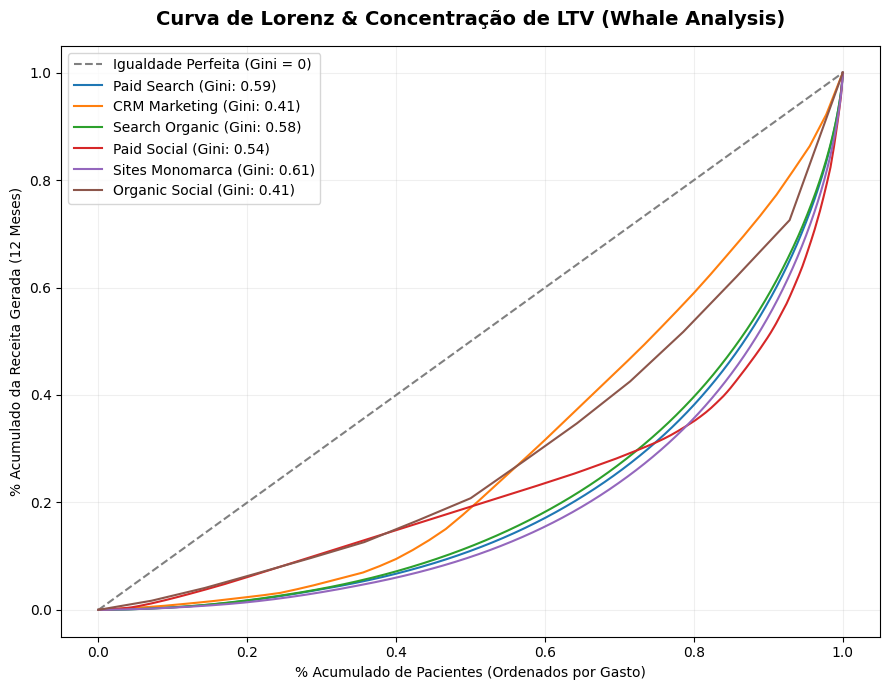

In [21]:
def calcular_gini_lorenz(df_whale, subcanal):
    # Filtrar e ordenar a receita de forma ascendente
    receitas = df_whale[df_whale['subcanal_aquisicao'] == subcanal]['receita_total_12m'].sort_values().values
    n = len(receitas)
    
    if n == 0: return 0, np.array([]), np.array([])
    
    # Cálculo clássico do Coeficiente de Gini
    index = np.arange(1, n + 1)
    gini = ((2 * index - n - 1) * receitas).sum() / (n * receitas.sum())
    
    # Construção da Curva de Lorenz
    cum_pacientes = np.arange(0, n + 1) / n
    cum_receita = np.insert(np.cumsum(receitas) / receitas.sum(), 0, 0)
    
    return gini, cum_pacientes, cum_receita

# Plotando a Whale Analysis para comparação de Subcanais
plt.figure(figsize=(9, 7))
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Igualdade Perfeita (Gini = 0)')

for canal in ["Paid Search", "CRM Marketing", "Search Organic","Paid Social", "Sites Monomarca","Organic Social"]:
    if canal in df_whale['subcanal_aquisicao'].unique():
        gini, c_pac, c_rec = calcular_gini_lorenz(df_whale, canal)
        plt.plot(c_pac, c_rec, label=f'{canal} (Gini: {gini:.2f})')

plt.title('Curva de Lorenz & Concentração de LTV (Whale Analysis)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('% Acumulado de Pacientes (Ordenados por Gasto)')
plt.ylabel('% Acumulado da Receita Gerada (12 Meses)')
plt.legend(loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Manual:

No Slope Analysis: Se o pico de velocidade marginal do CRM for em $M3$ e o do Paid Search em $M0$, você prova numericamente que Mídia Paga colhe valor imediato, mas o CRM possui efeito retardado e sustentável de ganho de LTV.

Na Whale Analysis: Um coeficiente de Gini acima de 0.70 acende a luz amarela. Significa que o faturamento está concentrado em pouquíssimos CPFs (ex: pacientes crônicos ou oncológicos). Estratégias de blindagem de convênio e fidelização precisam focar nesse topo.

Na Hazard Rate: O mês onde a linha vermelha der o maior salto (ex: se pular de 5% para 25% entre o mês 2 e 3) indica o momento exato em que o paciente desiste de voltar para a Dasa. Suas réguas automatizadas de CRM devem ser disparadas exatamente um mês antes desse pico de risco.

In [20]:
# Agrupar a receita total do primeiro mês (Mês 0) por Grupo de Exames dentro do Monomarca
if "grupo_exames" in df_mono.columns:
    mix_produtos = df_mono[df_mono["mes_desde_aquisicao"] == 0].groupby("grupo_exames").agg(
        volume_pacientes=("tamanho_coorte", "sum"),
        receita_inicial=("receita_mes", "sum")
    ).reset_index()
    
    mix_produtos["share_pacientes_%"] = (mix_produtos["volume_pacientes"] / mix_produtos["volume_pacientes"].sum()) * 100
    print(mix_produtos.sort_values(by="share_pacientes_%", ascending=False))
else:
    print("A coluna 'grupo_exames' não está nesta base. Verifique o notebook LTV_Matriz_Retencao_2.ipynb")

NameError: name 'df_mono' is not defined